# **Data Over Bridges**
---

## Introduction
This project focuses on choosing a metric to determine the best neighborhood in Pittsburgh. We all agreed that we wanted something that was equally creative yet practical so we could find a data set for each submetric. We ended up choosing sustainability because there are many ways to measure sustainability and determine how a location is eco-friendly. It was somewhat difficult to come up with a metric because all of us wanted to find a submetric that was interesting to us but also had a dataset relevant to our topic. We looked at measuring bestness as “things to do” (restaurants, activities, etc.) but were struggling to find data sets that could fit those submetrics, so that’s how we started to lean towards sustainability.

---

## The Metric
Our group’s chosen metric is sustainability. Sustainability is a great measure of the quality of an area because a clean, sustainable, eco-friendly environment is key. This allowed us to come up with several unique submetrics because there are so many ways to look at and measure sustainability. You can talk about pollution, but you can also talk about the creative methods an area is using to remain sustainable and environmentally friendly. 

The first dataset, "Grow Pittsburgh Food Gardens" contains the grower's identifing information as well as information pertaining to the location of each garden registered with Grow Pittsburgh. We labeled this dataset under the submetric of self-sufficiency because of the produce that the gardens are able to provide to their neighborhoods causing a lessened reliance, however small, on outside food sources.

The second dataset, “POGOH Station Locations” houses information about the POGOH bikeshare system here in Pittsburgh. This was a good data set to use because POGOH has locations in almost every Pittsburgh neighborhood and is a business growing consistently. We’re calling this submetric accessibility because a lot of the data has to do with numbers of bikes and station locations, so the numbers measure how accessible this sustainable transportation method is.



Here we set Jupyter Lab to start digging through our data.

In [3]:
import pandas as pd
import numpy as np
import fpsnippets

---

## The Best Neighborhood


### Self-Suffuciency through Grow Gardens
The first aspect of Sustainability that we decided to analyze was Self-Suffuciency. We decided to do this through the presence of grow gardens throughout the neighborhoods of Pittsburgh.

Grow Gardens not only offer fresh food, but they also build communities and teach valuable life skills!

This data set comes from the Grow Pittsburgh on the WPRDC.

In [4]:
gardens = pd.read_csv("https://data.wprdc.org/dataset/0d8c9708-3f01-48c4-adff-04d29825c9a2/resource/dbdfcb3e-8fa5-4468-9b05-f69562798f7a/download/grow-pgh-food-gardens.csv")
gardens.head(80)

,urban_grower,grower_id,category,url,street_address,city,state,zip_code,country,latitude,longitude
0,Angora Gardens,584,sustainability-fund-site|other,https://www.growpittsburgh.org/directory/garde...,3 Muse Lane,White Oak,Pennsylvania,15131.0,US,40.404686,-79.862095
1,Everybody's Garden,586,sustainability-fund-site|other,https://www.growpittsburgh.org/directory/garde...,301 West Elizabeth Street,Pittsburgh,Pennsylvania,15207.0,US,40.406546,-79.945442
2,EvGard Extension,587,other,https://www.growpittsburgh.org/directory/garde...,NaN,Pittsburgh,Pennsylvania,15201.0,US,40.406377,-79.945559
3,Glen Hazel Communiuty Garden,588,other,https://www.growpittsburgh.org/directory/garde...,Johnston Avenue at Roselle Drive,Pittsburgh,Pennsylvania,15207.0,US,40.406040,-79.931253
4,Grow Pittsburgh,589,grow-pittsburgh-site,https://www.growpittsburgh.org/directory/garde...,6587 Hamilton Avenue #2W,Pittsburgh,Pennsylvania,15206.0,US,40.458481,-79.911381
...,...,...,...,...,...,...,...,...,...,...,...
75,Penn Hills Community Garden,734,allegheny-grows-site|sustainability-fund-site,https://www.growpittsburgh.org/directory/garde...,1162 Jefferson Road,Penn Hills,Pennsylvania,15235.0,US,40.447638,-79.798817
76,Stanton Heights Allegheny Cemetery Community G...,735,sustainability-fund-site,https://www.growpittsburgh.org/directory/garde...,Stanton Avenue,Pittsburgh,Pennsylvania,15201.0,US,40.473711,-79.961237
77,The Harry Orlando Memorial Community Garden,736,community-garden,https://www.growpittsburgh.org/directory/garde...,2205 5th Avenue,Pittsburgh,Pennsylvania,15219.0,US,40.438247,-79.973943
78,The Octopus Garden,738,community-garden,https://www.growpittsburgh.org/directory/garde...,133 S. Aiken Avenue,Pittsburgh,Pennsylvania,15206.0,US,40.463591,-79.936771


This data is not very helpful on its own, but we can use the longitude and latitude to find which neighborhoods each grow garden is located in. Through the use of fpsnippets, each coordinate represents a spot within a neighborhood. This is how we can figure out which neighborhood has the most grow gardens.

In [5]:
gardens_adj = pd.DataFrame(gardens)

neighborhoods_list = []

for index, row in gardens.iterrows():
    lat = row['latitude']
    long = row['longitude']
    neighborhoods_list.append(fpsnippets.geo_to_neighborhood(lat, long))

list_to_series = pd.Series(neighborhoods_list, name = 'neighborhoods')

gardens_adj['neighborhoods'] = list_to_series

gardens_adj.head(80)

,urban_grower,grower_id,category,url,street_address,city,state,zip_code,country,latitude,longitude,neighborhoods
0,Angora Gardens,584,sustainability-fund-site|other,https://www.growpittsburgh.org/directory/garde...,3 Muse Lane,White Oak,Pennsylvania,15131.0,US,40.404686,-79.862095,None
1,Everybody's Garden,586,sustainability-fund-site|other,https://www.growpittsburgh.org/directory/garde...,301 West Elizabeth Street,Pittsburgh,Pennsylvania,15207.0,US,40.406546,-79.945442,Hazelwood
2,EvGard Extension,587,other,https://www.growpittsburgh.org/directory/garde...,NaN,Pittsburgh,Pennsylvania,15201.0,US,40.406377,-79.945559,Hazelwood
3,Glen Hazel Communiuty Garden,588,other,https://www.growpittsburgh.org/directory/garde...,Johnston Avenue at Roselle Drive,Pittsburgh,Pennsylvania,15207.0,US,40.406040,-79.931253,Glen Hazel
4,Grow Pittsburgh,589,grow-pittsburgh-site,https://www.growpittsburgh.org/directory/garde...,6587 Hamilton Avenue #2W,Pittsburgh,Pennsylvania,15206.0,US,40.458481,-79.911381,Larimer
...,...,...,...,...,...,...,...,...,...,...,...,...
75,Penn Hills Community Garden,734,allegheny-grows-site|sustainability-fund-site,https://www.growpittsburgh.org/directory/garde...,1162 Jefferson Road,Penn Hills,Pennsylvania,15235.0,US,40.447638,-79.798817,None
76,Stanton Heights Allegheny Cemetery Community G...,735,sustainability-fund-site,https://www.growpittsburgh.org/directory/garde...,Stanton Avenue,Pittsburgh,Pennsylvania,15201.0,US,40.473711,-79.961237,Central Lawrenceville
77,The Harry Orlando Memorial Community Garden,736,community-garden,https://www.growpittsburgh.org/directory/garde...,2205 5th Avenue,Pittsburgh,Pennsylvania,15219.0,US,40.438247,-79.973943,West Oakland
78,The Octopus Garden,738,community-garden,https://www.growpittsburgh.org/directory/garde...,133 S. Aiken Avenue,Pittsburgh,Pennsylvania,15206.0,US,40.463591,-79.936771,Bloomfield


This data shows a bit of a clear picture, but it still has grow gardens with no neighborhood associated with them. Let's group this data together by neighborhood to show which neighborhoods have the most gardens.

In [6]:
gardens_by_neighborhood = gardens_adj.groupby("neighborhoods").count().loc[:,"urban_grower"].sort_values(ascending=False)
gardens_by_neighborhood[:10]

neighborhoods
Garfield                 4
East Liberty             4
Point Breeze             4
West Oakland             3
Larimer                  3
Hazelwood                3
South Oakland            3
Central Lawrenceville    3
Middle Hill              2
Bloomfield               2
Name: urban_grower, dtype: int64

This is a good representation of which neighborhoods have the most grow gardens, but we can show a greater set through a bar graph.

<Axes: title={'center': 'Number of Grow Gardens by Neighborhood in Pittsburgh'}, xlabel='neighborhoods'>

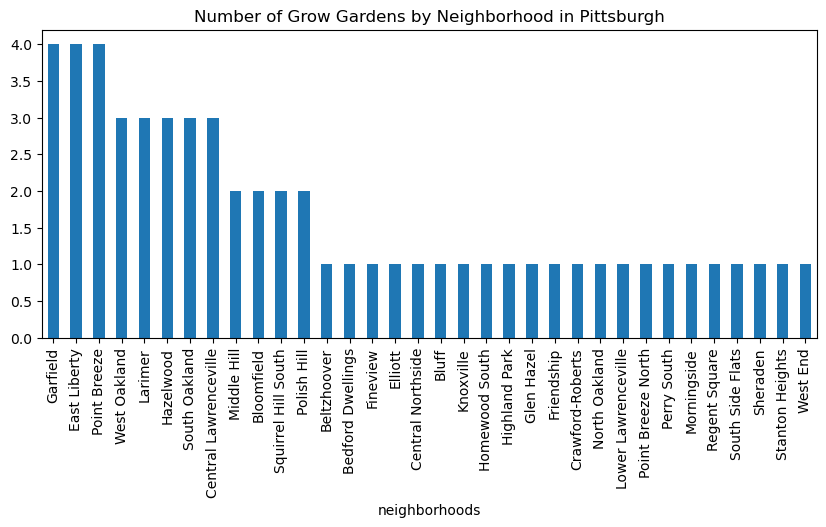

In [7]:
gardens_by_neighborhood.plot.bar(title = "Number of Grow Gardens by Neighborhood in Pittsburgh", figsize = (10,4))

### Accessibility through POGOH
The second aspect of Sustainability that we decided to analyze was Accessibility. We decided to do this through the variety of POGOH station locations throughout the neighborhoods of Pittsburgh.

POGOH is the bike share service offered throughout pittsburgh allowing users to rent regular and e-assist bikes!

This data set comes from the POGOH on the WPRDC.

In [9]:
pogoh = pd.read_csv('pogoh.tsv',sep='\t')
pogoh.head(60)

,_id,Id,Name,Total Docks,Latitude,Longitude
0,1,1,Pierce St & Summerlea St,19,40.456507,-79.932331
1,2,2,Eliza Furnace Trail & Swineburne St,15,40.425800,-79.953400
2,3,3,Centre Ave & Addison St,15,40.444600,-79.978300
3,4,4,Burns White Center at 3 Crossings,15,40.456400,-79.980000
4,5,5,Allegheny Station,19,40.448301,-80.018007
5,6,6,10th St & Penn Ave,15,40.444653,-79.996074
6,7,7,Liberty Ave & Gross St,15,40.459588,-79.945204
7,8,8,Glasshouse,15,40.432900,-80.003000
8,9,9,South Side Trail & S 4th St,15,40.431336,-79.995106
9,10,10,Zulema St & Coltart Ave,19,40.436055,-79.956827


While this data tells us the streets and coordinates of the stations, it does not directly tell us the neighborhoods, so let's use fpsnippets to locate the neighborhoods where the stations are located.

In [13]:
pogoh_adj = pd.DataFrame(pogoh)

neighborhoods_list = []

for index, row in pogoh.iterrows():
    lat = row['Latitude']
    long = row['Longitude']
    neighborhoods_list.append(fpsnippets.geo_to_neighborhood(lat, long))

list_to_series = pd.Series(neighborhoods_list, name = 'neighborhoods')

pogoh_adj['neighborhoods'] = list_to_series

pogoh_adj.head(60)

,_id,Id,Name,Total Docks,Latitude,Longitude,neighborhoods
0,1,1,Pierce St & Summerlea St,19,40.456507,-79.932331,Shadyside
1,2,2,Eliza Furnace Trail & Swineburne St,15,40.425800,-79.953400,Hazelwood
2,3,3,Centre Ave & Addison St,15,40.444600,-79.978300,Middle Hill
3,4,4,Burns White Center at 3 Crossings,15,40.456400,-79.980000,Strip District
4,5,5,Allegheny Station,19,40.448301,-80.018007,Chateau
5,6,6,10th St & Penn Ave,15,40.444653,-79.996074,Central Business District
6,7,7,Liberty Ave & Gross St,15,40.459588,-79.945204,Bloomfield
7,8,8,Glasshouse,15,40.432900,-80.003000,South Shore
8,9,9,South Side Trail & S 4th St,15,40.431336,-79.995106,South Side Flats
9,10,10,Zulema St & Coltart Ave,19,40.436055,-79.956827,Central Oakland


Now that we have the neighborhoods of the stations we can group the stations together by neighborhood and see which Pittsburgh neighborhood has the most stations.

In [14]:
stations_by_neighborhood = pogoh_adj.groupby("neighborhoods").count().loc[:,"_id"].sort_values(ascending=False)
stations_by_neighborhood[:10]

neighborhoods
Central Oakland              7
Central Business District    6
Shadyside                    5
North Oakland                4
South Side Flats             4
Bloomfield                   3
Homewood South               3
Hazelwood                    3
Strip District               3
Allegheny Center             2
Name: _id, dtype: int64

We can even take this one step further by creating a bar graph to show a larger set of neighborhoods and their number of POGOH stations.

<Axes: title={'center': 'Number of Stations per Neighborhood'}, xlabel='neighborhoods'>

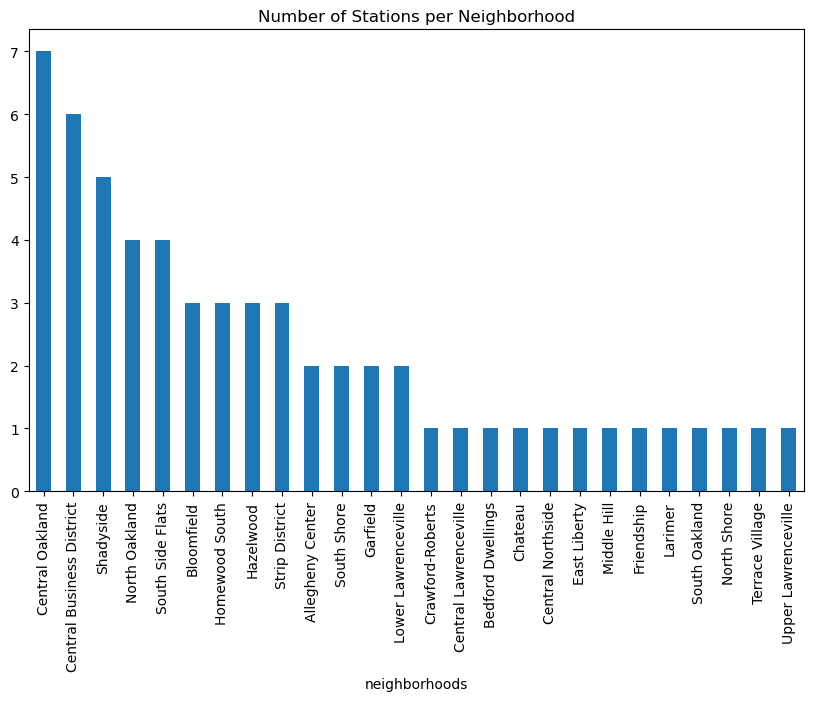

In [15]:
stations_by_neighborhood.plot.bar(title = "Number of Stations per Neighborhood", figsize = (10,6))

## Conclusion